# Telco Customer Churn — Feature Engineering

**Goal:** Transform raw columns into features that help the model learn
*business signals*, not just raw values.

Features are built in four stages:
1. Load and sanity-check the cleaned data from `01_eda.ipynb`
2. Construct new engineered features motivated by EDA findings
3. Encode all categorical variables consistently (no leftover strings)
4. Save a clean, fully numeric feature matrix for modelling

> **Design note on encoding strategy:**
> - Binary Yes/No columns → 0/1 integer mapping
> - Multi-class nominal columns → one-hot encoding (`drop_first=True` to
>   avoid perfect multicollinearity, which matters for Logistic Regression)
> - We do **not** double-encode: if a signal is captured by an engineered
>   feature (e.g. `electronic_check`), we skip it in the OHE step


## 1. Setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load and validate cleaned data

We load from `telco_cleaned.csv` produced by notebook 01.
A quick sanity check confirms shape, dtypes, and no unexpected nulls.


In [35]:
df = pd.read_csv('../data/telco_cleaned.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print(df.dtypes)


Shape: 7,032 rows × 22 columns

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
Churn_Binary          int64
dtype: object


In [36]:
# Confirm no nulls made it through
assert df.isnull().sum().sum() == 0, "Unexpected nulls found — check notebook 01"
print("No nulls. All clear.")


No nulls. All clear.


## 3. Construct engineered features

Each feature below is motivated by a specific business insight from the EDA.


In [38]:
# ── Feature 1: Tenure buckets ────────────────────────────────────────────────
# Rationale: Churn risk is highly non-linear with tenure.
# New customers (0–6 months) churn at ~50%; loyal customers (4+ years) barely at all.
# Bucketing captures this threshold effect without assuming linearity.
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6mo', '6-12mo', '1-2yr', '2-4yr', '4+yr'],
    include_lowest=True,
)

# ── Feature 2: Above-median monthly spend ────────────────────────────────────
# Rationale: Flags customers paying more than the median — from EDA, high
# monthly charges are associated with higher churn risk.
median_charge = df['MonthlyCharges'].median()
df['above_median_spend'] = (df['MonthlyCharges'] > median_charge).astype(int)
print(f"Median MonthlyCharges: ${median_charge:.2f}")

# ── Feature 3: Spend per month of tenure ─────────────────────────────────────
# Rationale: Normalises TotalCharges by tenure to get average monthly spend.
# More stable than TotalCharges alone (which is highly collinear with tenure).
# +1 avoids divide-by-zero for tenure=0 customers.
df['spend_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)

# ── Feature 4: Number of subscribed services ─────────────────────────────────
# Rationale: Customers with more services are "stickier" — switching costs
# are higher. From EDA, more services → lower churn rate.
service_cols = [
    'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

# ── Feature 5: Has security or support service ───────────────────────────────
# Rationale: "Commitment" services like OnlineSecurity and TechSupport
# signal that a customer has invested in the platform beyond basic connectivity.
df['has_security_or_support'] = (
    (df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')
).astype(int)

# ── Feature 6: Electronic check flag ─────────────────────────────────────────
# Rationale: EDA showed electronic check users churn at ~45% vs ~15–20% for
# automatic payment methods. Isolating this as a binary flag gives it
# explicit weight; it will NOT be re-encoded in the OHE step below.
df['electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

print("\nEngineered features preview:")
eng_cols = [
    'tenure_bucket', 'above_median_spend', 'spend_per_tenure',
    'num_services', 'has_security_or_support', 'electronic_check',
]
df[eng_cols].head(8)


Median MonthlyCharges: $70.35

Engineered features preview:


,tenure_bucket,above_median_spend,spend_per_tenure,num_services,has_security_or_support,electronic_check
0,0-6mo,0,14.925000,1,0,1
1,2-4yr,0,53.985714,3,1,0
2,0-6mo,0,36.050000,3,1,0
3,2-4yr,0,40.016304,3,1,0
4,0-6mo,1,50.550000,1,0,1
5,6-12mo,1,91.166667,5,0,1
6,1-2yr,1,84.756522,4,0,0
7,6-12mo,0,27.445455,1,1,0


### 3.1 Validate engineered features against churn

Quick churn-rate check on each new feature to confirm it carries signal.


In [39]:
print("Churn rate by tenure bucket:")
print(df.groupby('tenure_bucket', observed=True)['Churn_Binary'].mean().round(3))
print()
print("Churn rate by number of services:")
print(df.groupby('num_services')['Churn_Binary'].mean().round(3))
print()
print("Churn rate: has_security_or_support")
print(df.groupby('has_security_or_support')['Churn_Binary'].mean().round(3))
print()
print("Churn rate: electronic_check")
print(df.groupby('electronic_check')['Churn_Binary'].mean().round(3))
print()
print("Churn rate: above_median_spend")
print(df.groupby('above_median_spend')['Churn_Binary'].mean().round(3))


Churn rate by tenure bucket:
tenure_bucket
0-6mo     0.533
6-12mo    0.359
1-2yr     0.287
2-4yr     0.204
4+yr      0.095
Name: Churn_Binary, dtype: float64

Churn rate by number of services:
num_services
0    0.438
1    0.212
2    0.329
3    0.365
4    0.314
5    0.256
6    0.226
7    0.124
8    0.053
Name: Churn_Binary, dtype: float64

Churn rate: has_security_or_support
has_security_or_support
0    0.335
1    0.171
Name: Churn_Binary, dtype: float64

Churn rate: electronic_check
electronic_check
0    0.171
1    0.453
Name: Churn_Binary, dtype: float64

Churn rate: above_median_spend
above_median_spend
0    0.180
1    0.352
Name: Churn_Binary, dtype: float64


## 4. Encode categorical variables

**Strategy:**
- **Binary columns** (Yes/No): map directly to 0/1
- **Multi-class columns**: one-hot encode with `drop_first=True` to avoid
  the dummy variable trap (perfect multicollinearity)
- **`PaymentMethod`**: we already captured the key signal via `electronic_check`,
  so we exclude it from OHE to avoid redundancy
- **`tenure_bucket`**: already engineered; OHE'd here for model use
- Columns used only to build engineered features (`customerID`, `Churn`,
  `PaperlessBilling`, raw service strings) are dropped at the end


In [40]:
# ── Binary Yes/No columns → 0/1 ─────────────────────────────────────────────
binary_map = {
    'Partner':          ('Yes', 'No'),
    'Dependents':       ('Yes', 'No'),
    'PhoneService':     ('Yes', 'No'),
    'PaperlessBilling': ('Yes', 'No'),
}
for col, (pos, _) in binary_map.items():
    df[col] = (df[col] == pos).astype(int)

# Gender: Male=1, Female=0
df['gender'] = (df['gender'] == 'Male').astype(int)

print("Binary encoding done.")
df[['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']].head(4)


Binary encoding done.


,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0


In [41]:
# ── Multi-class columns → one-hot encoding ───────────────────────────────────
# drop_first=True drops one dummy per group → avoids perfect multicollinearity
# PaymentMethod is excluded because electronic_check already captures its
# key signal; including it would double-encode the same information.

ohe_cols = ['Contract', 'InternetService', 'tenure_bucket']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

print(f"Shape after OHE: {df.shape}")
print("\nNew OHE columns:")
new_cols = [c for c in df.columns if any(c.startswith(p+'_') for p in ohe_cols)]
print(new_cols)


Shape after OHE: (7032, 33)

New OHE columns:
['Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'tenure_bucket_6-12mo', 'tenure_bucket_1-2yr', 'tenure_bucket_2-4yr', 'tenure_bucket_4+yr']


In [42]:
# ── Drop columns no longer needed ────────────────────────────────────────────
# - customerID: identifier, not a feature
# - Churn: raw string version; Churn_Binary is our target
# - PaymentMethod: signal captured by electronic_check
# - Raw service string columns: signal captured by num_services /
#   has_security_or_support; keeping them as strings would require further
#   encoding and introduces redundancy with engineered features

to_drop = [
    'customerID', 'Churn', 'PaymentMethod',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
]
# Only drop columns that actually exist (defensive)
to_drop = [c for c in to_drop if c in df.columns]
df.drop(columns=to_drop, inplace=True)

print(f"Shape after dropping raw columns: {df.shape}")


Shape after dropping raw columns: (7032, 23)


## 5. Final feature matrix check

Before saving, we confirm:
- No leftover string/object columns
- No nulls
- Target column (`Churn_Binary`) is present and correctly distributed


In [43]:
# Check for any remaining object columns
obj_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if obj_cols:
    print(f"WARNING — non-numeric columns still present: {obj_cols}")
else:
    print("All columns are numeric.")

# Null check
null_count = df.isnull().sum().sum()
print(f"Total nulls: {null_count}")

# Target distribution
print("\nTarget distribution:")
print(df['Churn_Binary'].value_counts())
print(f"Churn rate: {df['Churn_Binary'].mean():.1%}")


All columns are numeric.
Total nulls: 0

Target distribution:
Churn_Binary
0    5163
1    1869
Name: count, dtype: int64
Churn rate: 26.6%


In [44]:
# Full column list and dtypes
print(f"Final feature matrix: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print(df.dtypes.to_string())


Final feature matrix: 7,032 rows × 23 columns

gender                           int64
SeniorCitizen                    int64
Partner                          int64
Dependents                       int64
tenure                           int64
PhoneService                     int64
PaperlessBilling                 int64
MonthlyCharges                 float64
TotalCharges                   float64
Churn_Binary                     int64
above_median_spend               int64
spend_per_tenure               float64
num_services                     int64
has_security_or_support          int64
electronic_check                 int64
Contract_One year                int64
Contract_Two year                int64
InternetService_Fiber optic      int64
InternetService_No               int64
tenure_bucket_6-12mo             int64
tenure_bucket_1-2yr              int64
tenure_bucket_2-4yr              int64
tenure_bucket_4+yr               int64


In [45]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn_Binary,...,has_security_or_support,electronic_check,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,tenure_bucket_6-12mo,tenure_bucket_1-2yr,tenure_bucket_2-4yr,tenure_bucket_4+yr
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,1,0,0,0,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,0,0,0,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,1,0,0,0,0,0,1,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,1,0,0,1,0,0,0,0,0


## 6. Feature correlation with Churn

A quick correlation check confirms the engineered features carry signal
and helps spot any unexpected redundancy before modelling.


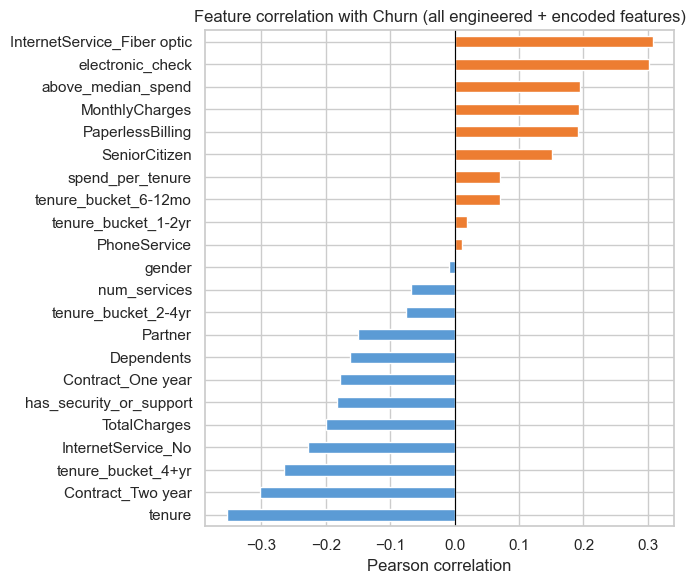

In [46]:
corr = df.corr()['Churn_Binary'].drop('Churn_Binary').sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#ED7D31' if v > 0 else '#5B9BD5' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature correlation with Churn (all engineered + encoded features)')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.savefig('../data/plots/feature_correlation.png', dpi=150)
plt.show()


**What to look for:**
- `Contract_Two year` and `Contract_One year` should be strongly *negative* — long contracts retain customers
- `tenure` should be strongly negative
- `electronic_check`, `above_median_spend` should be positive
- If `spend_per_tenure` and `MonthlyCharges` have nearly identical correlations,
  consider dropping one before modelling (collinearity)


## 7. Save feature matrix

Save the fully numeric, model-ready dataframe to `telco_features.csv`.


In [47]:
df.to_csv('../data/telco_features.csv', index=False)
print(f"Saved telco_features.csv  ({df.shape[0]:,} rows × {df.shape[1]} columns)")
print("Ready for 03_modeling.ipynb")


Saved telco_features.csv  (7,032 rows × 23 columns)
Ready for 03_modeling.ipynb
